## Data Crawling & Cleaning

##### Nạp các thư viện cần thiết.

In [1]:
import os
from pathlib import Path
from functools import reduce
import requests
import pandas as pd
import numpy as np
import pyodbc

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils import resample

In [2]:
import warnings
warnings.filterwarnings('ignore')

##### Khai báo thông tin máy chủ và tạo kết nối tới SQL Server.

In [3]:
server = r'DESKTOP-B1NE7EL'
database = 'Final_Project'

conn_str = (
    "DRIVER={ODBC Driver 18 for SQL Server};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

conn = pyodbc.connect(conn_str)
print("Connected successfully.")

df_test = pd.read_sql("SELECT @@SERVERNAME AS server_name, DB_NAME() AS db_name", conn)
df_test

Connected successfully.


,server_name,db_name
0,DESKTOP-B1NE7EL,Final_Project


##### Chuẩn bị nơi lưu file và định nghĩa các chu kỳ NHANES sẽ sử dụng.

In [4]:
OUT_DIR = Path("Data")
RAW_DIR = OUT_DIR / "raw_nhanes"
OUT_DIR.mkdir(exist_ok=True)
RAW_DIR.mkdir(exist_ok=True)

CYCLES = [
    {"folder": "2005", "suffix": "D", "name": "2005-2006"},
    {"folder": "2007", "suffix": "E", "name": "2007-2008"},
    {"folder": "2009", "suffix": "F", "name": "2009-2010"},
    {"folder": "2011", "suffix": "G", "name": "2011-2012"},
    {"folder": "2013", "suffix": "H", "name": "2013-2014"},
    {"folder": "2015", "suffix": "I", "name": "2015-2016"},
    {"folder": "2017", "suffix": "J", "name": "2017-2018"},
]

FILES = {
    "DEMO":  ["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH3"],
    "BMX":   ["SEQN", "BMXBMI", "BMXWT", "BMXHT", "BMXWAIST"],
    "BPX":   ["SEQN", "BPXSY1", "BPXSY2", "BPXSY3", "BPXDI1", "BPXDI2", "BPXDI3"],
    "TCHOL": ["SEQN", "LBXTC"],
    "GLU":   ["SEQN", "LBXGLU"],
    "DIQ":   ["SEQN", "DIQ010"],
    "SMQ":   ["SEQN", "SMQ020"],
    "PAQ":   ["SEQN", "PAQ605"],
    "MCQ":   ["SEQN", "MCQ160B"],
}

##### Định nghĩa các hàm tạo URL, tải file XPT và đọc dữ liệu theo từng chu kỳ.

In [5]:
def make_url(cycle, file_code: str) -> str:
    return f"https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/{cycle['folder']}/DataFiles/{file_code}_{cycle['suffix']}.XPT"

def download_file(url: str, dest: Path):
    print(f"[DOWNLOAD] {url}")
    r = requests.get(url, timeout=120, stream=True)
    r.raise_for_status()
    with open(dest, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)

def ensure_local_xpt(cycle, file_code: str) -> Path:
    local_path = RAW_DIR / f"{file_code}_{cycle['suffix']}.XPT"
    if not local_path.exists():
        download_file(make_url(cycle, file_code), local_path)
    return local_path

def read_xpt_local(cycle, file_code: str, keep_cols: list[str]) -> pd.DataFrame:
    path = ensure_local_xpt(cycle, file_code)
    print(f"[READ] {path.name}")
    df = pd.read_sas(path)
    df.columns = [str(c).strip() for c in df.columns]
    keep_cols = [c for c in keep_cols if c in df.columns]
    df = df[keep_cols].copy()
    df["cycle"] = cycle["name"]
    return df

##### Đọc dữ liệu từ các file NHANES và ghép các chu kỳ thành từng bảng hoàn chỉnh.

In [6]:
all_data = {k: [] for k in FILES.keys()}

for cycle in CYCLES:
    print(f"\n===== Processing cycle: {cycle['name']} =====")
    for file_code, cols in FILES.items():
        df_tmp = read_xpt_local(cycle, file_code, cols)
        all_data[file_code].append(df_tmp)

demo  = pd.concat(all_data["DEMO"], ignore_index=True)
bmx   = pd.concat(all_data["BMX"], ignore_index=True)
bpx   = pd.concat(all_data["BPX"], ignore_index=True)
tchol = pd.concat(all_data["TCHOL"], ignore_index=True)
glu   = pd.concat(all_data["GLU"], ignore_index=True)
diq   = pd.concat(all_data["DIQ"], ignore_index=True)
smq   = pd.concat(all_data["SMQ"], ignore_index=True)
paq   = pd.concat(all_data["PAQ"], ignore_index=True)
mcq   = pd.concat(all_data["MCQ"], ignore_index=True)

print("Done loading all cycles.")
print("DEMO:", demo.shape)
print("BMX :", bmx.shape)
print("BPX :", bpx.shape)
print("MCQ :", mcq.shape)


===== Processing cycle: 2005-2006 =====
[DOWNLOAD] https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2005/DataFiles/DEMO_D.XPT
[READ] DEMO_D.XPT
[DOWNLOAD] https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2005/DataFiles/BMX_D.XPT
[READ] BMX_D.XPT
[DOWNLOAD] https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2005/DataFiles/BPX_D.XPT
[READ] BPX_D.XPT
[DOWNLOAD] https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2005/DataFiles/TCHOL_D.XPT
[READ] TCHOL_D.XPT
[DOWNLOAD] https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2005/DataFiles/GLU_D.XPT
[READ] GLU_D.XPT
[DOWNLOAD] https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2005/DataFiles/DIQ_D.XPT
[READ] DIQ_D.XPT
[DOWNLOAD] https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2005/DataFiles/SMQ_D.XPT
[READ] SMQ_D.XPT
[DOWNLOAD] https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2005/DataFiles/PAQ_D.XPT
[READ] PAQ_D.XPT
[DOWNLOAD] https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2005/DataFiles/MCQ_D.XPT
[READ] MCQ_D.XPT

===== Processing cycle: 2007-2008 =====
[DOWNLOAD] https://wwwn.cdc.go

Chuẩn bị các hàm upload dữ liệu lên SQL Server: Chuẩn hóa tên cột, ánh xạ kiểu dữ liệu từ pandas sang SQL, tạo bảng tự động và chèn dữ liệu từ DataFrame vào cơ sở dữ liệu.

In [7]:
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]
    return out

def sql_type_from_dtype(dtype) -> str:
    if pd.api.types.is_integer_dtype(dtype):
        return "BIGINT NULL"
    if pd.api.types.is_float_dtype(dtype):
        return "FLOAT NULL"
    return "NVARCHAR(255) NULL"

def create_table_from_df(conn, table_name: str, df: pd.DataFrame):
    df = normalize_columns(df)
    cursor = conn.cursor()

    cursor.execute(f"""
    IF OBJECT_ID('{table_name}', 'U') IS NOT NULL
        DROP TABLE {table_name};
    """)
    conn.commit()

    col_defs = []
    for col in df.columns:
        sql_type = sql_type_from_dtype(df[col].dtype)
        col_defs.append(f"[{col}] {sql_type}")

    create_sql = f"CREATE TABLE {table_name} ({', '.join(col_defs)});"
    cursor.execute(create_sql)
    conn.commit()

def insert_df(conn, table_name: str, df: pd.DataFrame):
    df = normalize_columns(df).copy()
    df = df.where(pd.notnull(df), None)

    cols = [f"[{c}]" for c in df.columns]
    placeholders = ", ".join(["?"] * len(cols))
    insert_sql = f"INSERT INTO {table_name} ({', '.join(cols)}) VALUES ({placeholders})"

    clean_data = df.astype(object).where(pd.notnull(df), None).values.tolist()

    cursor = conn.cursor()
    cursor.fast_executemany = True
    cursor.executemany(insert_sql, clean_data)
    conn.commit()

def upload_raw_table(conn, table_name: str, df: pd.DataFrame):
    create_table_from_df(conn, table_name, df)
    insert_df(conn, table_name, df)
    print(f"Uploaded {table_name}: {df.shape}")

def run_sql(conn, sql: str, msg: str = ""):
    cursor = conn.cursor()
    cursor.execute(sql)
    conn.commit()
    if msg:
        print(f"[DONE] {msg}")

In [8]:
def display_sql(conn, sql, title):    
    df = pd.read_sql(sql, conn)
    return df

##### Đẩy các bảng dữ liệu thô lên SQL Server để chuẩn bị cho bước biến đổi bằng SQL.

In [9]:
upload_raw_table(conn, "dbo.demo_raw", demo)
upload_raw_table(conn, "dbo.bmx_raw", bmx)
upload_raw_table(conn, "dbo.bpx_raw", bpx)
upload_raw_table(conn, "dbo.tchol_raw", tchol)
upload_raw_table(conn, "dbo.glu_raw", glu)
upload_raw_table(conn, "dbo.diq_raw", diq)
upload_raw_table(conn, "dbo.smq_raw", smq)
upload_raw_table(conn, "dbo.paq_raw", paq)
upload_raw_table(conn, "dbo.mcq_raw", mcq)

Uploaded dbo.demo_raw: (70190, 5)
Uploaded dbo.bmx_raw: (67364, 6)
Uploaded dbo.bpx_raw: (67364, 8)
Uploaded dbo.tchol_raw: (56377, 3)
Uploaded dbo.glu_raw: (23043, 3)
Uploaded dbo.diq_raw: (67203, 3)
Uploaded dbo.smq_raw: (49542, 3)
Uploaded dbo.paq_raw: (62256, 3)
Uploaded dbo.mcq_raw: (67203, 3)


##### Cấu trúc các bảng dữ liệu thô trong SQL Server

Các bảng raw được tạo tự động từ DataFrame và upload lên SQL Server để lưu dữ liệu gần với dạng gốc của NHANES. Tất cả các cột đều cho phép `NULL`, và kiểu dữ liệu SQL được suy ra tự động từ kiểu dữ liệu trong pandas.

| Bảng SQL | Các cột chính | Mô tả |
|---|---|---|
| `dbo.demo_raw` | `SEQN`, `RIDAGEYR`, `RIAGENDR`, `RIDRETH3`, `cycle` | Thông tin nhân khẩu học: mã định danh, tuổi, giới tính, chủng tộc, chu kỳ khảo sát |
| `dbo.bmx_raw` | `SEQN`, `BMXBMI`, `BMXWT`, `BMXHT`, `BMXWAIST`, `cycle` | Chỉ số cơ thể: BMI, cân nặng, chiều cao, vòng eo |
| `dbo.bpx_raw` | `SEQN`, `BPXSY1`, `BPXSY2`, `BPXSY3`, `BPXDI1`, `BPXDI2`, `BPXDI3`, `cycle` | Các lần đo huyết áp tâm thu và tâm trương |
| `dbo.tchol_raw` | `SEQN`, `LBXTC`, `cycle` | Cholesterol toàn phần |
| `dbo.glu_raw` | `SEQN`, `LBXGLU`, `cycle` | Glucose máu lúc đói |
| `dbo.diq_raw` | `SEQN`, `DIQ010`, `cycle` | Thông tin liên quan đến tiểu đường |
| `dbo.smq_raw` | `SEQN`, `SMQ020`, `cycle` | Thông tin về tiền sử hút thuốc |
| `dbo.paq_raw` | `SEQN`, `PAQ605`, `cycle` | Thông tin về hoạt động thể lực mức vừa |
| `dbo.mcq_raw` | `SEQN`, `MCQ160B`, `cycle` | Biến liên quan đến suy tim, dùng làm target sau khi chuẩn hóa |

##### Tạo các bảng trung gian cho từng nhóm biến và chuẩn hóa lại cấu trúc dữ liệu.

In [10]:
sql_demo = """
IF OBJECT_ID('dbo.demo', 'U') IS NOT NULL DROP TABLE dbo.demo;
SELECT
    CAST(SEQN AS BIGINT) AS id,
    cycle,
    CAST(RIDAGEYR AS FLOAT) AS age,
    CASE 
        WHEN CAST(RIAGENDR AS INT) = 1 THEN 'Male'
        WHEN CAST(RIAGENDR AS INT) = 2 THEN 'Female'
        ELSE NULL
    END AS sex,
    CAST(RIDRETH3 AS FLOAT) AS race_code
INTO dbo.demo
FROM dbo.demo_raw;
"""

sql_bmx = """
IF OBJECT_ID('dbo.bmx', 'U') IS NOT NULL DROP TABLE dbo.bmx;
SELECT
    CAST(SEQN AS BIGINT) AS id,
    cycle,
    CAST(BMXBMI AS FLOAT) AS bmi,
    CAST(BMXWT AS FLOAT) AS weight_kg,
    CAST(BMXHT AS FLOAT) AS height_cm,
    CAST(BMXWAIST AS FLOAT) AS waist_cm
INTO dbo.bmx
FROM dbo.bmx_raw;
"""

sql_bpx = """
IF OBJECT_ID('dbo.bpx', 'U') IS NOT NULL DROP TABLE dbo.bpx;
SELECT
    CAST(SEQN AS BIGINT) AS id,
    cycle,
    (
        COALESCE(CAST(BPXSY1 AS FLOAT), 0) +
        COALESCE(CAST(BPXSY2 AS FLOAT), 0) +
        COALESCE(CAST(BPXSY3 AS FLOAT), 0)
    ) / NULLIF(
        (CASE WHEN BPXSY1 IS NOT NULL THEN 1 ELSE 0 END) +
        (CASE WHEN BPXSY2 IS NOT NULL THEN 1 ELSE 0 END) +
        (CASE WHEN BPXSY3 IS NOT NULL THEN 1 ELSE 0 END), 0
    ) AS systolic_bp,
    (
        COALESCE(CAST(BPXDI1 AS FLOAT), 0) +
        COALESCE(CAST(BPXDI2 AS FLOAT), 0) +
        COALESCE(CAST(BPXDI3 AS FLOAT), 0)
    ) / NULLIF(
        (CASE WHEN BPXDI1 IS NOT NULL THEN 1 ELSE 0 END) +
        (CASE WHEN BPXDI2 IS NOT NULL THEN 1 ELSE 0 END) +
        (CASE WHEN BPXDI3 IS NOT NULL THEN 1 ELSE 0 END), 0
    ) AS diastolic_bp
INTO dbo.bpx
FROM dbo.bpx_raw;
"""

sql_tchol = """
IF OBJECT_ID('dbo.tchol', 'U') IS NOT NULL DROP TABLE dbo.tchol;
SELECT
    CAST(SEQN AS BIGINT) AS id,
    cycle,
    CAST(LBXTC AS FLOAT) AS total_cholesterol
INTO dbo.tchol
FROM dbo.tchol_raw;
"""

sql_glu = """
IF OBJECT_ID('dbo.glu', 'U') IS NOT NULL DROP TABLE dbo.glu;
SELECT
    CAST(SEQN AS BIGINT) AS id,
    cycle,
    CAST(LBXGLU AS FLOAT) AS fasting_glucose
INTO dbo.glu
FROM dbo.glu_raw;
"""

sql_diq = """
IF OBJECT_ID('dbo.diq', 'U') IS NOT NULL DROP TABLE dbo.diq;
SELECT
    CAST(SEQN AS BIGINT) AS id,
    cycle,
    CASE
        WHEN CAST(DIQ010 AS INT) = 1 THEN 1
        WHEN CAST(DIQ010 AS INT) = 2 THEN 0
        ELSE NULL
    END AS diabetes
INTO dbo.diq
FROM dbo.diq_raw;
"""

sql_smq = """
IF OBJECT_ID('dbo.smq', 'U') IS NOT NULL DROP TABLE dbo.smq;
SELECT
    CAST(SEQN AS BIGINT) AS id,
    cycle,
    CASE
        WHEN CAST(SMQ020 AS INT) = 1 THEN 1
        WHEN CAST(SMQ020 AS INT) = 2 THEN 0
        ELSE NULL
    END AS smoking_100_cigs_life
INTO dbo.smq
FROM dbo.smq_raw;
"""

sql_paq = """
IF OBJECT_ID('dbo.paq', 'U') IS NOT NULL DROP TABLE dbo.paq;
SELECT
    CAST(SEQN AS BIGINT) AS id,
    cycle,
    CASE
        WHEN CAST(PAQ605 AS INT) = 1 THEN 1
        WHEN CAST(PAQ605 AS INT) = 2 THEN 0
        ELSE NULL
    END AS moderate_activity
INTO dbo.paq
FROM dbo.paq_raw;
"""

sql_mcq = """
IF OBJECT_ID('dbo.mcq', 'U') IS NOT NULL DROP TABLE dbo.mcq;
SELECT
    CAST(SEQN AS BIGINT) AS id,
    cycle,
    CASE
        WHEN CAST(MCQ160B AS INT) = 1 THEN 1
        WHEN CAST(MCQ160B AS INT) = 2 THEN 0
        ELSE NULL
    END AS heart_failure
INTO dbo.mcq
FROM dbo.mcq_raw;
"""

for sql, name in [
    (sql_demo, "demo"),
    (sql_bmx, "bmx"),
    (sql_bpx, "bpx"),
    (sql_tchol, "tchol"),
    (sql_glu, "glu"),
    (sql_diq, "diq"),
    (sql_smq, "smq"),
    (sql_paq, "paq"),
    (sql_mcq, "mcq"),
]:
    run_sql(conn, sql, f"create {name}")

[DONE] create demo
[DONE] create bmx
[DONE] create bpx
[DONE] create tchol
[DONE] create glu
[DONE] create diq
[DONE] create smq
[DONE] create paq
[DONE] create mcq


##### Kết hợp các bảng trung gian thành bảng phân tích hoàn chỉnh cho bài toán suy tim.

In [11]:
sql_final = """
IF OBJECT_ID('dbo.data', 'U') IS NOT NULL DROP TABLE dbo.data;

SELECT
    d.id,
    d.cycle,
    d.age,
    d.sex,
    b.bmi,
    b.weight_kg,
    b.height_cm,
    b.waist_cm,
    p.systolic_bp,
    p.diastolic_bp,
    tc.total_cholesterol,
    g.fasting_glucose,
    di.diabetes,
    s.smoking_100_cigs_life,
    pa.moderate_activity,
    m.heart_failure
INTO dbo.data
FROM dbo.demo d
LEFT JOIN dbo.bmx b
    ON d.id = b.id AND d.cycle = b.cycle
LEFT JOIN dbo.bpx p
    ON d.id = p.id AND d.cycle = p.cycle
LEFT JOIN dbo.tchol tc
    ON d.id = tc.id AND d.cycle = tc.cycle
LEFT JOIN dbo.glu g
    ON d.id = g.id AND d.cycle = g.cycle
LEFT JOIN dbo.diq di
    ON d.id = di.id AND d.cycle = di.cycle
LEFT JOIN dbo.smq s
    ON d.id = s.id AND d.cycle = s.cycle
LEFT JOIN dbo.paq pa
    ON d.id = pa.id AND d.cycle = pa.cycle
LEFT JOIN dbo.mcq m
    ON d.id = m.id AND d.cycle = m.cycle
WHERE d.age >= 18
  AND m.heart_failure IS NOT NULL;
"""

run_sql(conn, sql_final, "create merged heart-failure dataset")

[DONE] create merged heart-failure dataset


##### Điều kiện lọc sau khi ghép

| Điều kiện | Ý nghĩa |
|---|---|
| `d.age >= 18` | Chỉ giữ người trưởng thành |
| `m.heart_failure IS NOT NULL` | Chỉ giữ các dòng có nhãn suy tim hợp lệ |

##### Cấu trúc bảng `dbo.data` sau khi ghép

| Cột | Ý nghĩa |
|---|---|
| `id` | Mã định danh người tham gia |
| `cycle` | Chu kỳ khảo sát NHANES |
| `age` | Tuổi |
| `sex` | Giới tính |
| `bmi` | Chỉ số khối cơ thể |
| `weight_kg` | Cân nặng |
| `height_cm` | Chiều cao |
| `waist_cm` | Vòng eo |
| `systolic_bp` | Huyết áp tâm thu trung bình |
| `diastolic_bp` | Huyết áp tâm trương trung bình |
| `total_cholesterol` | Cholesterol toàn phần |
| `fasting_glucose` | Glucose máu lúc đói |
| `diabetes` | Biến nhị phân về tiểu đường |
| `smoking_100_cigs_life` | Biến nhị phân về hút thuốc |
| `moderate_activity` | Biến nhị phân về vận động mức vừa |
| `heart_failure` | Biến mục tiêu suy tim |

##### Lấy bảng dữ liệu cuối từ SQL Server để tiếp tục làm sạch và phân tích.

In [12]:
dataset = pd.read_sql("SELECT * FROM dbo.data", conn)
print(dataset.shape)
dataset.head()

(39636, 16)


,id,cycle,age,sex,bmi,weight_kg,height_cm,waist_cm,systolic_bp,diastolic_bp,total_cholesterol,fasting_glucose,diabetes,smoking_100_cigs_life,moderate_activity,heart_failure
0,31154,2005-2006,62.0,Male,26.98,88.2,180.8,103.2,147.333333,75.333333,190.0,NaN,0.0,1.0,NaN,0
1,31155,2005-2006,38.0,Male,25.61,90.5,188.0,87.7,125.333333,63.333333,170.0,100.0,0.0,0.0,NaN,0
2,31172,2005-2006,20.0,Female,46.89,119.3,159.5,NaN,NaN,NaN,211.0,NaN,0.0,1.0,NaN,0
3,31187,2005-2006,22.0,Female,25.26,78.6,176.4,87.4,110.666667,63.333333,181.0,78.0,0.0,0.0,NaN,0
4,31190,2005-2006,72.0,Male,27.49,84.0,174.8,103.0,143.333333,72.666667,172.0,NaN,0.0,0.0,NaN,0


##### Giữ lại các biến quan trọng phục vụ phân tích và mô hình hóa.

In [13]:
selected_features = [
    "age",
    "sex",
    "bmi",
    "weight_kg",
    "height_cm",
    "waist_cm",
    "systolic_bp",
    "diastolic_bp",
    "total_cholesterol",
    "fasting_glucose",
    "diabetes",
    "smoking_100_cigs_life",
    "moderate_activity",
    "heart_failure"
]

dataset = dataset[selected_features].copy()
print(dataset.shape)
dataset.head()

(39636, 14)


,age,sex,bmi,weight_kg,height_cm,waist_cm,systolic_bp,diastolic_bp,total_cholesterol,fasting_glucose,diabetes,smoking_100_cigs_life,moderate_activity,heart_failure
0,62.0,Male,26.98,88.2,180.8,103.2,147.333333,75.333333,190.0,NaN,0.0,1.0,NaN,0
1,38.0,Male,25.61,90.5,188.0,87.7,125.333333,63.333333,170.0,100.0,0.0,0.0,NaN,0
2,20.0,Female,46.89,119.3,159.5,NaN,NaN,NaN,211.0,NaN,0.0,1.0,NaN,0
3,22.0,Female,25.26,78.6,176.4,87.4,110.666667,63.333333,181.0,78.0,0.0,0.0,NaN,0
4,72.0,Male,27.49,84.0,174.8,103.0,143.333333,72.666667,172.0,NaN,0.0,0.0,NaN,0


##### Chỉ giữ lại các dòng có nhãn suy tim hợp lệ để đảm bảo dữ liệu huấn luyện nhất quán.

In [14]:
dataset = dataset[dataset["heart_failure"].notna()].copy()

dataset["heart_failure"] = dataset["heart_failure"].astype(int)

numeric_cols = dataset.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ["id", "heart_failure"]]

for col in numeric_cols:
    dataset[col] = dataset[col].fillna(dataset[col].median())

dataset["sex"] = dataset["sex"].fillna(dataset["sex"].mode()[0])

print(dataset.isnull().sum())

age                      0
sex                      0
bmi                      0
weight_kg                0
height_cm                0
waist_cm                 0
systolic_bp              0
diastolic_bp             0
total_cholesterol        0
fasting_glucose          0
diabetes                 0
smoking_100_cigs_life    0
moderate_activity        0
heart_failure            0
dtype: int64


##### Chuyển đổi biến giới tính sang dạng số để tiện xử lý trong EDA và mô hình.

In [15]:
dataset = pd.get_dummies(dataset, columns=["sex"], drop_first=True)

print(dataset.shape)
dataset.head()

(39636, 14)


,age,bmi,weight_kg,height_cm,waist_cm,systolic_bp,diastolic_bp,total_cholesterol,fasting_glucose,diabetes,smoking_100_cigs_life,moderate_activity,heart_failure,sex_Male
0,62.0,26.98,88.2,180.8,103.2,147.333333,75.333333,190.0,101.0,0.0,1.0,0.0,0,True
1,38.0,25.61,90.5,188.0,87.7,125.333333,63.333333,170.0,100.0,0.0,0.0,0.0,0,True
2,20.0,46.89,119.3,159.5,98.0,121.333333,70.666667,211.0,101.0,0.0,1.0,0.0,0,False
3,22.0,25.26,78.6,176.4,87.4,110.666667,63.333333,181.0,78.0,0.0,0.0,0.0,0,False
4,72.0,27.49,84.0,174.8,103.0,143.333333,72.666667,172.0,101.0,0.0,0.0,0.0,0,True


In [16]:
dataset['sex_Male'] = dataset['sex_Male'].astype(int)

dataset.head()

,age,bmi,weight_kg,height_cm,waist_cm,systolic_bp,diastolic_bp,total_cholesterol,fasting_glucose,diabetes,smoking_100_cigs_life,moderate_activity,heart_failure,sex_Male
0,62.0,26.98,88.2,180.8,103.2,147.333333,75.333333,190.0,101.0,0.0,1.0,0.0,0,1
1,38.0,25.61,90.5,188.0,87.7,125.333333,63.333333,170.0,100.0,0.0,0.0,0.0,0,1
2,20.0,46.89,119.3,159.5,98.0,121.333333,70.666667,211.0,101.0,0.0,1.0,0.0,0,0
3,22.0,25.26,78.6,176.4,87.4,110.666667,63.333333,181.0,78.0,0.0,0.0,0.0,0,0
4,72.0,27.49,84.0,174.8,103.0,143.333333,72.666667,172.0,101.0,0.0,0.0,0.0,0,1


##### Định nghĩa hàm cắt ngưỡng outlier theo IQR cho các biến số.

In [17]:
def clip_outliers(df, cols):
    df = df.copy()
    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        df[col] = df[col].clip(lower, upper)
    return df

In [18]:
dataset = dataset.drop_duplicates()

In [19]:
for col in numeric_cols:
    dataset[col] = dataset[col].fillna(dataset[col].median())

eda_df = dataset.copy()

outlier_cols = [
    "bmi",
    "weight_kg",
    "height_cm",
    "waist_cm",
    "systolic_bp",
    "diastolic_bp",
    "total_cholesterol"
]

outlier_cols = [col for col in outlier_cols if col in eda_df.columns]

eda_df = clip_outliers(eda_df, outlier_cols)

## EDA & Visualization

##### Tổng quan dữ liệu: Kiểm tra kích thước dữ liệu, phân phối target và xem nhanh đầu dữ liệu.


In [20]:
print(dataset.shape)
print(dataset["heart_failure"].value_counts())
dataset.head()

(38570, 14)
heart_failure
0    37235
1     1335
Name: count, dtype: int64


,age,bmi,weight_kg,height_cm,waist_cm,systolic_bp,diastolic_bp,total_cholesterol,fasting_glucose,diabetes,smoking_100_cigs_life,moderate_activity,heart_failure,sex_Male
0,62.0,26.98,88.2,180.8,103.2,147.333333,75.333333,190.0,101.0,0.0,1.0,0.0,0,1
1,38.0,25.61,90.5,188.0,87.7,125.333333,63.333333,170.0,100.0,0.0,0.0,0.0,0,1
2,20.0,46.89,119.3,159.5,98.0,121.333333,70.666667,211.0,101.0,0.0,1.0,0.0,0,0
3,22.0,25.26,78.6,176.4,87.4,110.666667,63.333333,181.0,78.0,0.0,0.0,0.0,0,0
4,72.0,27.49,84.0,174.8,103.0,143.333333,72.666667,172.0,101.0,0.0,0.0,0.0,0,1


##### Tóm tắt nhanh các biến số để xem trung bình, độ lệch chuẩn và khoảng giá trị.


In [21]:
dataset.describe()

,age,bmi,weight_kg,height_cm,waist_cm,systolic_bp,diastolic_bp,total_cholesterol,fasting_glucose,diabetes,smoking_100_cigs_life,moderate_activity,heart_failure,sex_Male
count,38570.000000,38570.000000,38570.000000,38570.000000,38570.000000,38570.000000,3.857000e+04,38570.000000,38570.000000,38570.000000,38570.000000,38570.000000,38570.000000,38570.000000
mean,49.599481,29.139213,81.466782,166.937944,99.170669,124.201772,7.014150e+01,192.911123,104.960410,0.130672,0.444672,0.169432,0.034612,0.483822
std,17.894256,6.887486,21.424663,10.045752,15.742335,18.408595,1.267491e+01,40.491520,25.102812,0.337045,0.496936,0.375138,0.182798,0.499745
min,20.000000,13.180000,29.100000,123.300000,55.500000,64.666667,5.397605e-79,59.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34.000000,24.440000,66.700000,159.700000,88.500000,112.000000,6.333333e+01,166.000000,101.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,49.000000,28.040000,78.400000,166.700000,98.000000,121.333333,7.066667e+01,190.000000,101.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,64.000000,32.400000,92.400000,174.000000,107.900000,133.333333,7.733333e+01,215.000000,101.000000,0.000000,1.000000,0.000000,0.000000,1.000000
max,85.000000,130.210000,371.000000,204.500000,178.200000,270.000000,1.420000e+02,813.000000,584.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [22]:
dataset.duplicated().sum()

np.int64(0)

In [23]:
dataset.isnull().sum()

age                      0
bmi                      0
weight_kg                0
height_cm                0
waist_cm                 0
systolic_bp              0
diastolic_bp             0
total_cholesterol        0
fasting_glucose          0
diabetes                 0
smoking_100_cigs_life    0
moderate_activity        0
heart_failure            0
sex_Male                 0
dtype: int64

##### Xem danh sách cột hiện có và lưu snapshot dữ liệu ra CSV.


In [24]:
dataset.columns

Index(['age', 'bmi', 'weight_kg', 'height_cm', 'waist_cm', 'systolic_bp',
       'diastolic_bp', 'total_cholesterol', 'fasting_glucose', 'diabetes',
       'smoking_100_cigs_life', 'moderate_activity', 'heart_failure',
       'sex_Male'],
      dtype='str')

In [25]:
csv_path = OUT_DIR / "data.csv"
dataset.to_csv(csv_path, index=False, encoding="utf-8-sig")

### EDA: Factors Related To Heart Failure


##### Chọn các biến gốc sẽ phân tích mối liên hệ với suy tim.


In [26]:

binary_features = ["sex_Male", "diabetes", "smoking_100_cigs_life", "moderate_activity"]
binary_features = [col for col in binary_features if col in eda_df.columns]

numeric_features = [
    "age", "bmi", "total_cholesterol", "fasting_glucose",
    "systolic_bp", "diastolic_bp", "waist_cm", "height_cm"
]
numeric_features = [col for col in numeric_features if col in eda_df.columns]

bin_features = ["age", "bmi", "total_cholesterol", "fasting_glucose", "systolic_bp"]
bin_features = [col for col in bin_features if col in eda_df.columns]

print("Dataset shape:", eda_df.shape)
print("Numeric features:", numeric_features)
print("Binary features:", binary_features)


Dataset shape: (38570, 14)
Numeric features: ['age', 'bmi', 'total_cholesterol', 'fasting_glucose', 'systolic_bp', 'diastolic_bp', 'waist_cm', 'height_cm']
Binary features: ['sex_Male', 'diabetes', 'smoking_100_cigs_life', 'moderate_activity']


##### Xem số lượng và tỷ lệ bệnh suy tim trong toàn bộ dữ liệu.


Heart failure distribution:
heart_failure
0    37235
1     1335
Name: count, dtype: int64

Heart failure rate (%):
heart_failure
0    96.54
1     3.46
Name: proportion, dtype: float64


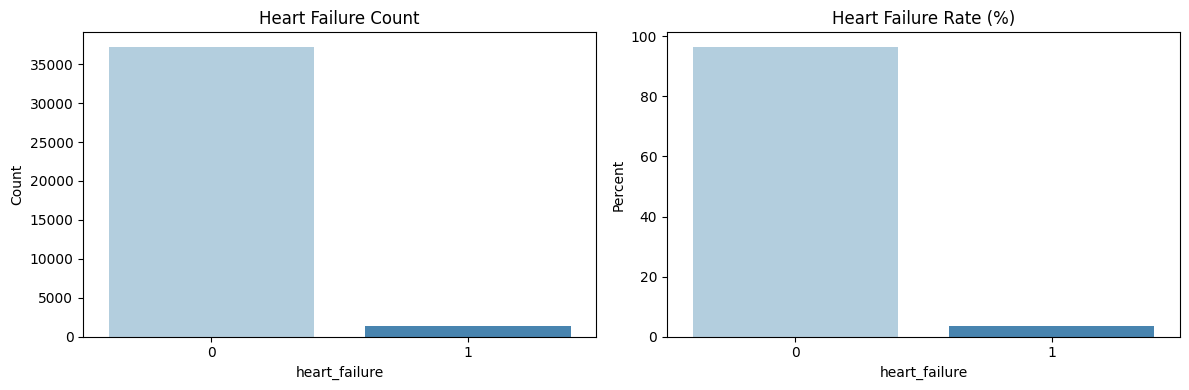

In [27]:
print("Heart failure distribution:")
print(eda_df["heart_failure"].value_counts().sort_index())
print("\nHeart failure rate (%):")
print((eda_df["heart_failure"].value_counts(normalize=True).sort_index() * 100).round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=eda_df, x="heart_failure", ax=axes[0], palette="Blues")
axes[0].set_title("Heart Failure Count")
axes[0].set_xlabel("heart_failure")
axes[0].set_ylabel("Count")

hf_rate = (eda_df["heart_failure"].value_counts(normalize=True).sort_index() * 100).round(2)
sns.barplot(x=hf_rate.index.astype(str), y=hf_rate.values, ax=axes[1], palette="Blues")
axes[1].set_title("Heart Failure Rate (%)")
axes[1].set_xlabel("heart_failure")
axes[1].set_ylabel("Percent")
plt.tight_layout()
plt.show()


##### Phân tích
Biến mục tiêu `heart_failure` bị lệch lớp khá mạnh, nghĩa là số người không suy tim lớn hơn rất nhiều so với số người suy tim. Về mặt phân tích, điều này nói lên hai vấn đề. Thứ nhất, nếu chỉ nhìn Accuracy thì rất dễ đánh giá sai chất lượng mô hình, vì mô hình có thể dự đoán phần lớn mẫu là `0` mà vẫn cho tỷ lệ đúng cao. Thứ hai, khi quan sát các biểu đồ EDA phía sau, cần chú ý nhiều hơn đến sự khác biệt về tỷ lệ hoặc về phân phối của nhóm `heart_failure = 1`, thay vì chỉ nhìn số lượng tuyệt đối.

Với một bài toán y tế như suy tim, sự mất cân bằng này cũng gợi ý rằng dữ liệu của nhóm bệnh có thể đa dạng hơn về đặc điểm lâm sàng, trong khi nhóm không bệnh chiếm ưu thế về số lượng. Vì vậy, các xu hướng nhìn thấy trong nhóm suy tim, dù số lượng nhỏ hơn, vẫn có giá trị phân tích rất lớn.

_____________

##### So sánh mean và median của các biến số giữa nhóm có và không suy tim.


In [28]:
target_summary = (
    eda_df.groupby("heart_failure")[numeric_features]
    .agg(["mean", "median"])
    .round(2)
)
print("Numeric summary by heart_failure:")
print(target_summary)


Numeric summary by heart_failure:
                 age           bmi        total_cholesterol         \
                mean median   mean median              mean median   
heart_failure                                                        
0              48.97   48.0  28.86  28.04            192.94  190.0   
1              67.25   70.0  31.09  29.71            175.90  176.0   

              fasting_glucose        systolic_bp         diastolic_bp         \
                         mean median        mean  median         mean median   
heart_failure                                                                  
0                      104.70  101.0      123.52  121.33        70.48  70.67   
1                      112.16  101.0      129.26  126.00        67.03  68.00   

              waist_cm        height_cm         
                  mean median      mean median  
heart_failure                                   
0                98.72   98.0    166.96  166.7  
1               10

Bảng thống kê theo `heart_failure` cho thấy một số khác biệt rất rõ giữa hai nhóm. Biến tách biệt mạnh nhất là `age`: nhóm không suy tim có tuổi trung bình khoảng `48.97`, trong khi nhóm suy tim là `67.25`; median cũng tăng từ `48` lên `70`. Đây là tín hiệu rất mạnh cho thấy tuổi là yếu tố liên hệ nổi bật nhất với suy tim trong bộ dữ liệu.

`BMI` cũng tăng ở nhóm suy tim, với mean từ `28.86` lên `31.09` và median từ `28.04` lên `29.71`. Điều này cho thấy nhóm suy tim không chỉ có vài ngoại lệ béo phì, mà toàn bộ phân phối BMI cũng dịch lên cao hơn. Nói cách khác, tình trạng thừa cân hoặc béo phì có liên hệ đáng kể với suy tim trong dữ liệu.

`Systolic_bp` tăng khá rõ ở nhóm suy tim, từ mean `123.52` lên `129.26`, median từ `121.33` lên `126.00`. Ngược lại, `diastolic_bp` lại thấp hơn ở nhóm suy tim, mean từ `70.48` xuống `67.03`, median từ `70.67` xuống `68.00`. Mẫu hình này rất đáng chú ý, vì nó gợi ý rằng khác biệt huyết áp ở nhóm suy tim không đơn thuần là tăng đều cả hai chỉ số, mà nghiêng về tăng huyết áp tâm thu trong khi huyết áp tâm trương không tăng tương ứng. Đây là một dấu hiệu gián tiếp cho thấy `pulse pressure` có thể lớn hơn ở nhóm suy tim, và điều đó hoàn toàn phù hợp với việc notebook sau này tạo thêm biến `pulse_pressure`.

`Fasting_glucose` có mean tăng từ `104.70` lên `112.16`, nhưng median của cả hai nhóm cùng là `101.0`. Điều này cho thấy glucose có khác biệt, nhưng khác biệt không nằm ở trung tâm phân phối mà nằm ở phần đuôi phía trên. Nói cách khác, nhóm suy tim có xu hướng xuất hiện nhiều giá trị glucose cao hơn, nhưng không phải toàn bộ nhóm bệnh đều có glucose cao. Đây là một biến có tín hiệu, nhưng tín hiệu đó mang tính ngưỡng hoặc lệch phải nhiều hơn là dịch chuyển đồng đều của toàn bộ phân phối.

`Waist_cm` tăng rõ từ mean `98.72` lên `106.10`, median từ `98.0` lên `102.2`, trong khi `height_cm` gần như không khác biệt giữa hai nhóm. Điều đó cho thấy sự khác biệt nằm ở tình trạng béo bụng hơn là ở tầm vóc cơ thể nói chung. Đây là một phát hiện có giá trị, vì nó giải thích vì sao các biến nhân trắc như vòng eo hoặc tỷ lệ eo/chiều cao có thể hữu ích cho mô hình.

Một điểm rất đáng chú ý là `total_cholesterol` lại thấp hơn ở nhóm suy tim, với mean từ `192.94` xuống `175.90`, median từ `190` xuống `176`. Đây là kết quả ngược với trực giác đơn giản “cholesterol cao thì nguy cơ tim mạch cao hơn”. Tuy nhiên, trong dữ liệu bệnh tim mạch và bệnh mạn tính, hiện tượng này không phải là không thể xảy ra; nó có thể phản ánh khác biệt về tuổi, điều trị thuốc, tình trạng dinh dưỡng, hoặc hiệu ứng được gọi là “cholesterol paradox”. Vì vậy, biến này cần được diễn giải rất thận trọng.

___

##### So sánh tỷ lệ suy tim theo giới tính, tiểu đường, hút thuốc và vận động.


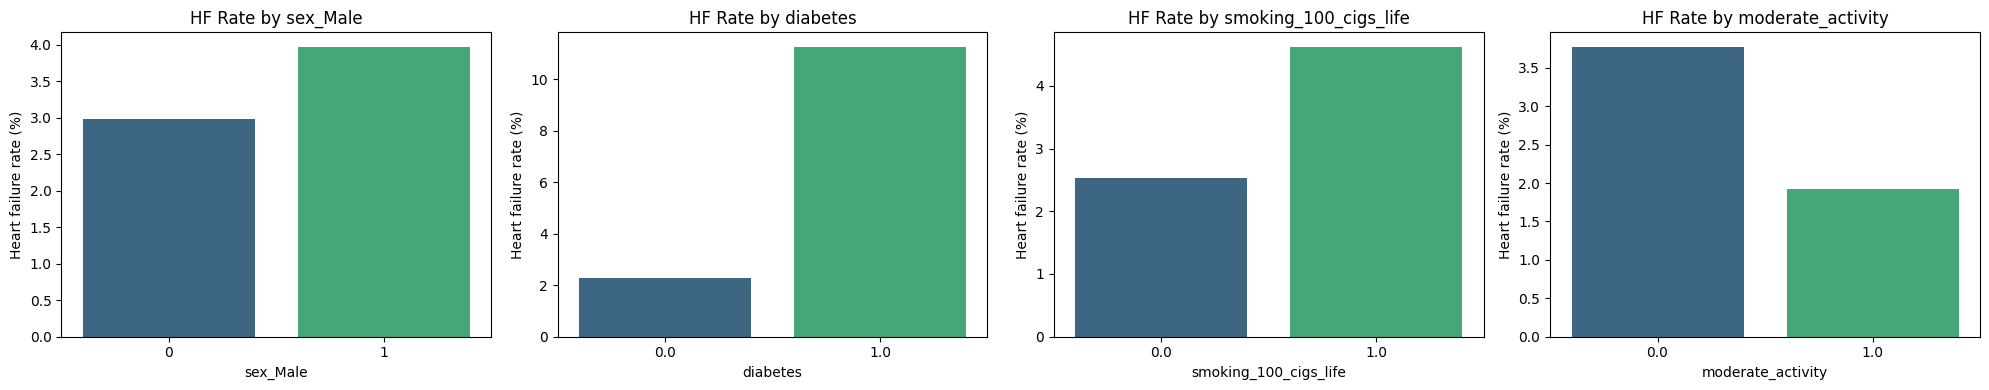

In [29]:
if binary_features:
    fig, axes = plt.subplots(1, len(binary_features), figsize=(5 * len(binary_features), 4))
    axes = np.atleast_1d(axes)
    for ax, feature in zip(axes, binary_features):
        plot_df = (
            eda_df.groupby(feature)["heart_failure"]
            .mean()
            .mul(100)
            .reset_index()
        )
        sns.barplot(data=plot_df, x=feature, y="heart_failure", ax=ax, palette="viridis")
        ax.set_title(f"HF Rate by {feature}")
        ax.set_ylabel("Heart failure rate (%)")
        ax.set_xlabel(feature)
    plt.tight_layout()
    plt.show()


Nhóm biến nhị phân như `sex_Male`, `diabetes`, `smoking_100_cigs_life` và `moderate_activity` giúp nhìn rõ hơn các yếu tố hành vi hoặc bệnh nền liên quan đến suy tim. Với các biến này, điều quan trọng không phải là số lượng người trong từng nhóm, mà là tỷ lệ suy tim trong từng nhóm.

Cột `diabetes = 1` cao hơn rõ rệt so với `diabetes = 0`, đó là tín hiệu rất có ý nghĩa vì nó củng cố kết quả từ `fasting_glucose`: rối loạn đường huyết và tiểu đường không chỉ liên quan ở mức chỉ số sinh học mà còn biểu hiện rõ ở mức bệnh nền, `moderate_activity = 1` có tỷ lệ suy tim thấp hơn, điều đó gợi ý rằng hoạt động thể lực có thể liên quan đến nguy cơ thấp hơn, hoặc ít nhất là nhóm ít vận động đang tập trung nhiều ca suy tim hơn.

Với `sex_Male`, tỷ lệ suy tim ở nam cao hơn nữ, có thể xem giới tính là một biến nền quan trọng, nhưng cần lưu ý rằng giới tính thường tương tác với tuổi, béo bụng, huyết áp và hút thuốc. Tương tự, nếu `smoking_100_cigs_life = 1` có tỷ lệ suy tim cao hơn, đây là tín hiệu hợp lý về mặt lâm sàng.

___

##### Dùng boxplot để xem sự khác biệt phân phối giữa hai nhóm target.


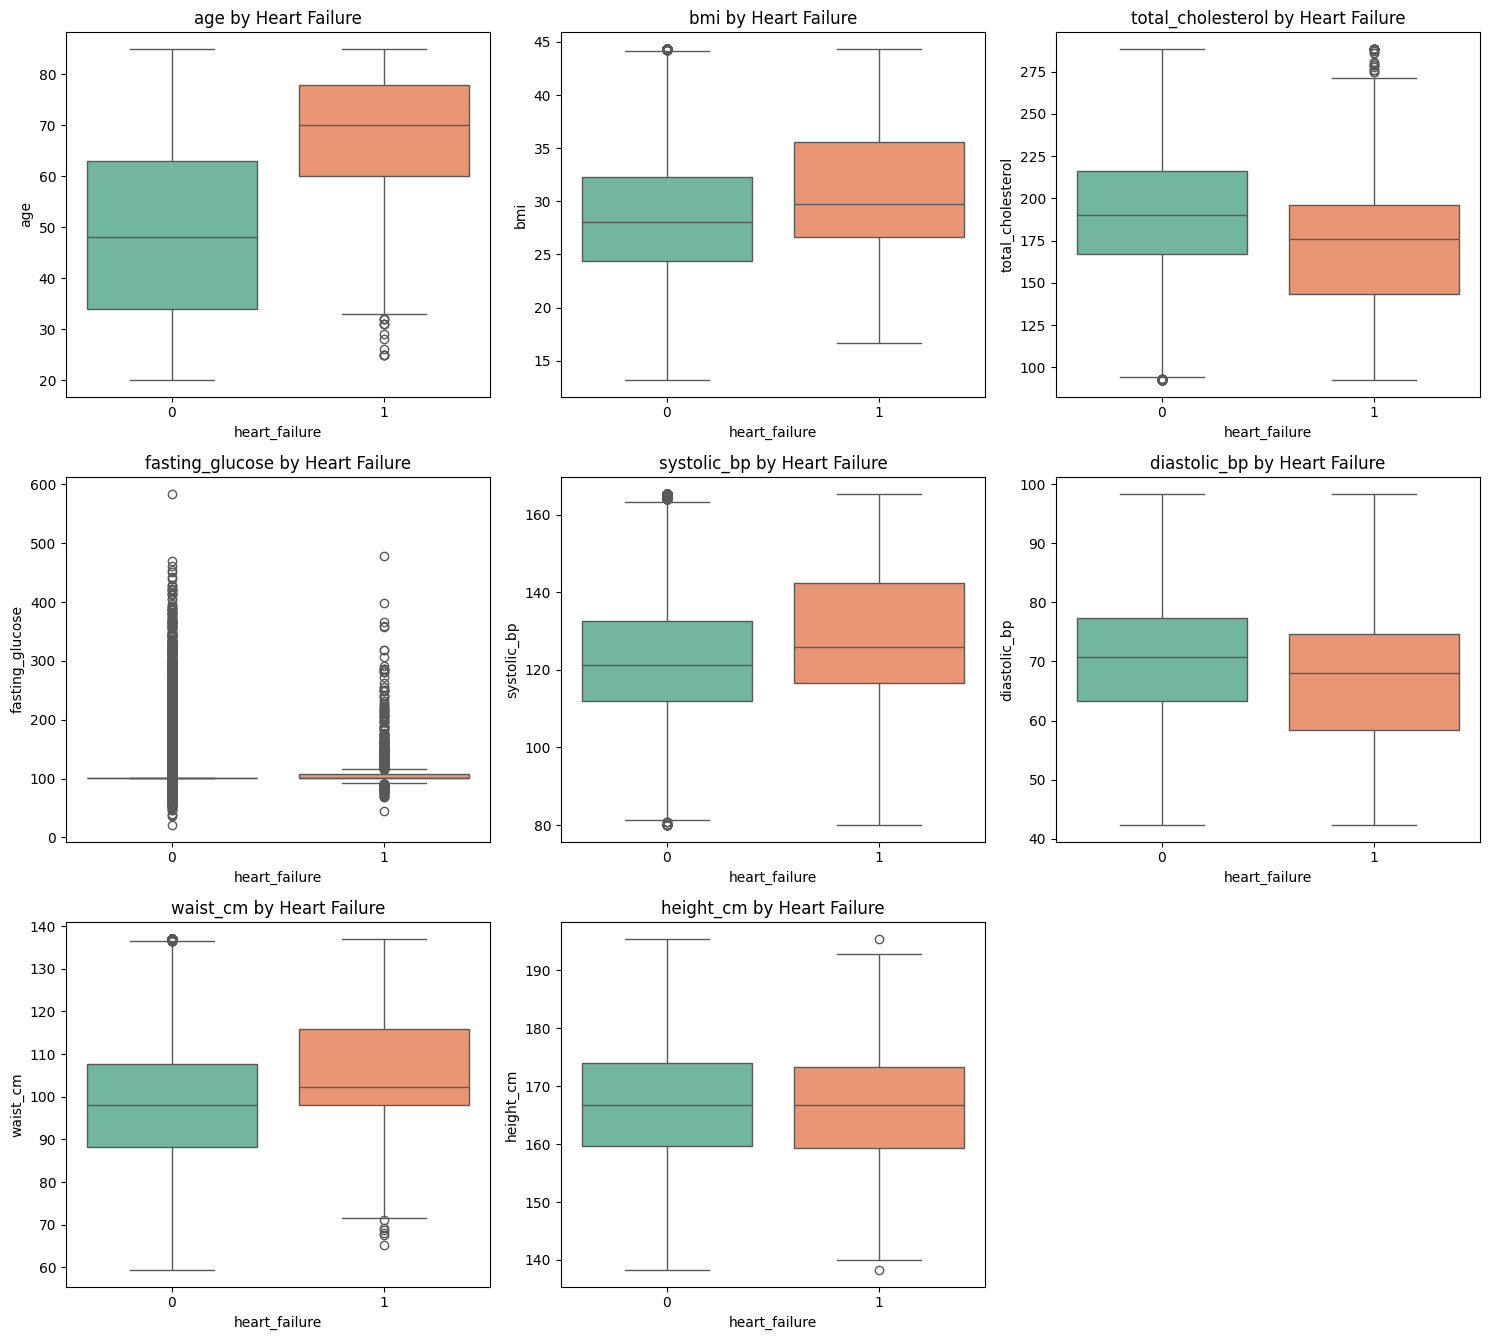

In [30]:
if numeric_features:
    ncols = 3
    nrows = int(np.ceil(len(numeric_features) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.5 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, feature in zip(axes, numeric_features):
        sns.boxplot(data=eda_df, x="heart_failure", y=feature, ax=ax, palette="Set2")
        ax.set_title(f"{feature} by Heart Failure")
    for ax in axes[len(numeric_features):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


Các boxplot cho thấy mức độ tách biệt giữa hai nhóm không đồng đều ở tất cả biến. `Age` là biến tách nhóm mạnh nhất: hộp của nhóm suy tim sẽ dịch lên khá rõ, thể hiện không chỉ mean mà cả median đều cao hơn đáng kể. Điều này cho thấy ảnh hưởng của tuổi là tương đối nhất quán trên toàn bộ phân phối, chứ không chỉ do vài giá trị ngoại lệ.

`BMI` và `waist_cm` nhiều khả năng cũng cho thấy hộp của nhóm suy tim nằm cao hơn, nhưng độ chồng lấn vẫn khá lớn. Điều đó có nghĩa là tình trạng thừa cân, béo phì và béo bụng có liên hệ với suy tim, nhưng chúng không phải là biến đủ mạnh để tự mình phân tách hoàn toàn hai nhóm. Nói cách khác, đây là những biến có giá trị khi kết hợp với tuổi, huyết áp và glucose.

Với `systolic_bp`, sự dịch chuyển lên của nhóm suy tim thường rõ hơn so với `diastolic_bp`. Trong khi đó, `diastolic_bp` có thể không tăng, thậm chí có xu hướng thấp hơn nhẹ ở nhóm suy tim. Mẫu hình này quan trọng vì nó cho thấy ý nghĩa lâm sàng không nằm ở từng trị số riêng lẻ mà nằm ở cấu trúc huyết áp tổng thể.

`Fasting_glucose` là một trường hợp đặc biệt. Vì median không chênh nhiều giữa hai nhóm, boxplot có thể không cho cảm giác khác biệt mạnh, nhưng phần đuôi trên của nhóm suy tim kéo dài hơn, điều đó phản ánh rằng nhóm bệnh có nhiều trường hợp tăng glucose rõ rệt hơn. Đây là kiểu tín hiệu không mạnh ở trung vị nhưng quan trọng ở phần phân phối trên.

`Total_cholesterol`, boxplot của nhóm suy tim thấp hơn, đây là kết quả nhất quán với bảng summary. Tuy nhiên, không nên vội kết luận rằng cholesterol thấp “nguy hiểm” hay cholesterol cao “không nguy hiểm”; nhiều khả năng đây là dấu hiệu của cấu trúc dữ liệu phức tạp hơn, nơi tuổi, điều trị và tình trạng bệnh cùng ảnh hưởng lên chỉ số này, hoặc tình trạng 'cholesterol paradox', 'obesity paradox'.

___

##### Chia biến số thành các nhóm quartile để xem xu hướng tăng giảm nguy cơ.


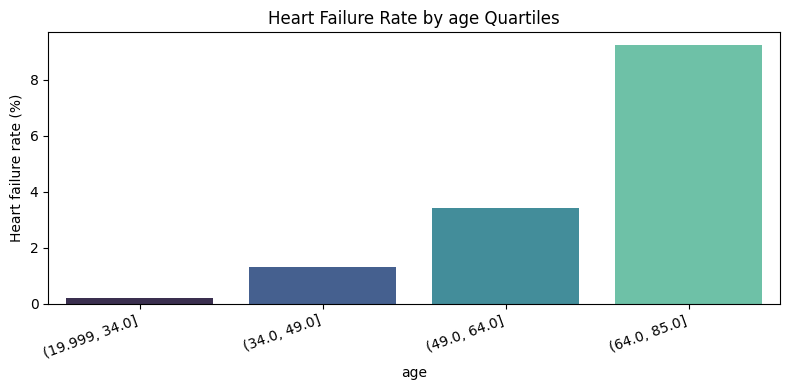

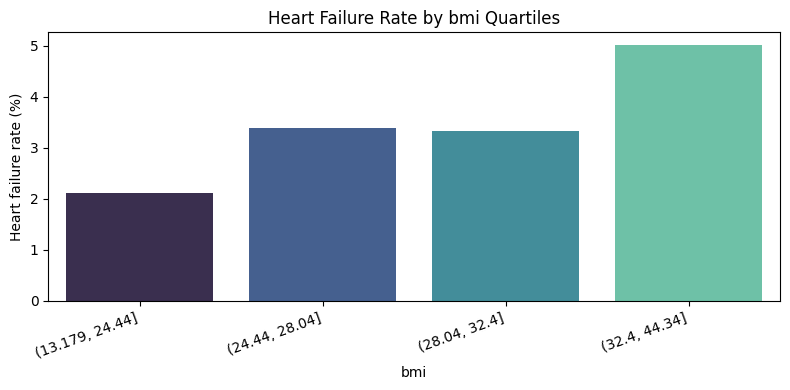

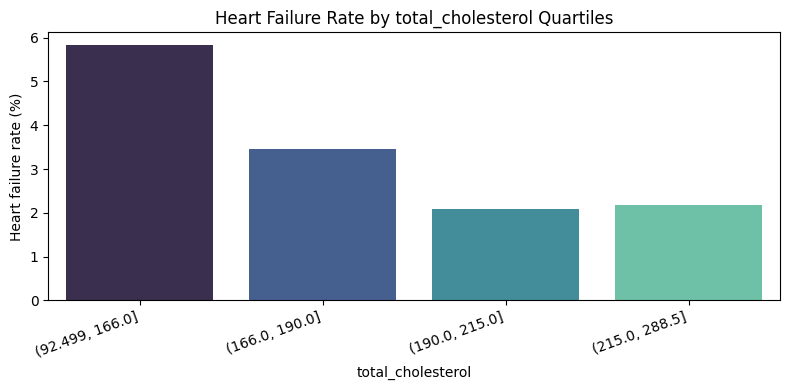

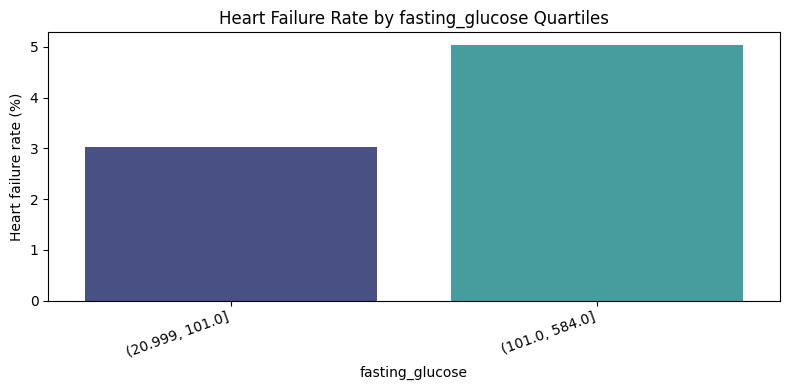

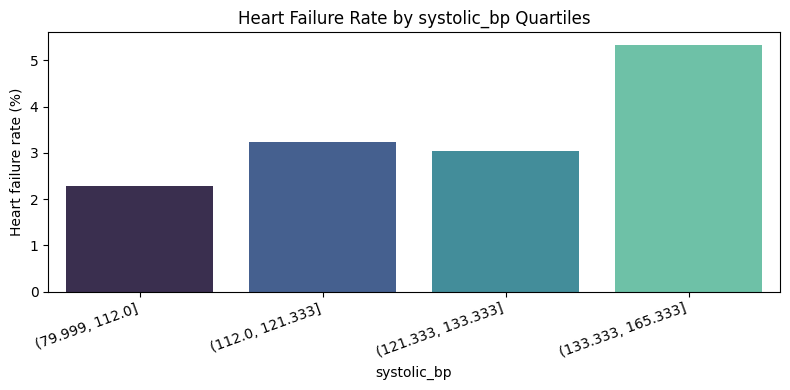

In [31]:
for feature in bin_features:
    temp_df = eda_df[[feature, "heart_failure"]].dropna().copy()
    temp_df[f"{feature}_bin"] = pd.qcut(temp_df[feature], q=4, duplicates="drop")
    rate_df = (
        temp_df.groupby(f"{feature}_bin", observed=False)["heart_failure"]
        .mean()
        .mul(100)
        .reset_index()
    )
    plt.figure(figsize=(8, 4))
    sns.barplot(data=rate_df, x=f"{feature}_bin", y="heart_failure", palette="mako")
    plt.title(f"Heart Failure Rate by {feature} Quartiles")
    plt.xlabel(feature)
    plt.ylabel("Heart failure rate (%)")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

Biểu đồ tỷ lệ suy tim theo quartile là nơi dễ nhìn thấy nhất xu hướng nguy cơ theo mức độ của từng biến. Với `age`, tỷ lệ suy tim tăng dần rõ ràng từ quartile thấp nhất đến cao nhất, có thể xem đây là bằng chứng trực quan mạnh nhất cho mối liên hệ giữa tuổi và suy tim trong dữ liệu. Không chỉ tuổi trung bình cao hơn ở nhóm suy tim, mà nguy cơ cũng tăng có hệ thống theo từng nhóm tuổi.

Với `BMI`, tỷ lệ suy tim tăng ở các quartile cao hơn nhưng không hoàn toàn tuyến tính, điều đó cho thấy béo phì có liên hệ với suy tim nhưng tác động có thể không đơn giản là “BMI càng cao thì nguy cơ càng tăng đều”. Rất có thể BMI chỉ phát huy tín hiệu mạnh khi đi cùng các yếu tố khác như tuổi, tiểu đường hoặc huyết áp.

Với `fasting_glucose`, đây là biểu đồ quan trọng hơn boxplot. Vì median giữa hai nhóm gần như giống nhau, sự khác biệt nhiều khả năng sẽ bộc lộ rõ hơn ở các quartile cao. Các nhóm glucose cao nhất có tỷ lệ suy tim tăng lên, điều đó xác nhận rằng glucose có quan hệ với suy tim theo kiểu ngưỡng hoặc theo đuôi phân phối, chứ không phải theo sự dịch chuyển đều của toàn bộ dữ liệu.

Với `systolic_bp`, tỷ lệ suy tim tăng theo quartile, đây là dấu hiệu rất phù hợp với phân tích lâm sàng: tăng huyết áp tâm thu liên quan chặt với nguy cơ tim mạch. Ngược lại, `total_cholesterol` không tạo ra xu hướng tăng rõ, hoặc thậm chí nhóm cao hơn không có tỷ lệ suy tim cao hơn, thì điều đó càng củng cố nhận định rằng vai trò của cholesterol trong dữ liệu này không đơn giản và có thể bị chi phối bởi các yếu tố nền khác.

___

##### Phân tích quan hệ giữa cholesterol và các yếu tố nguy cơ khác

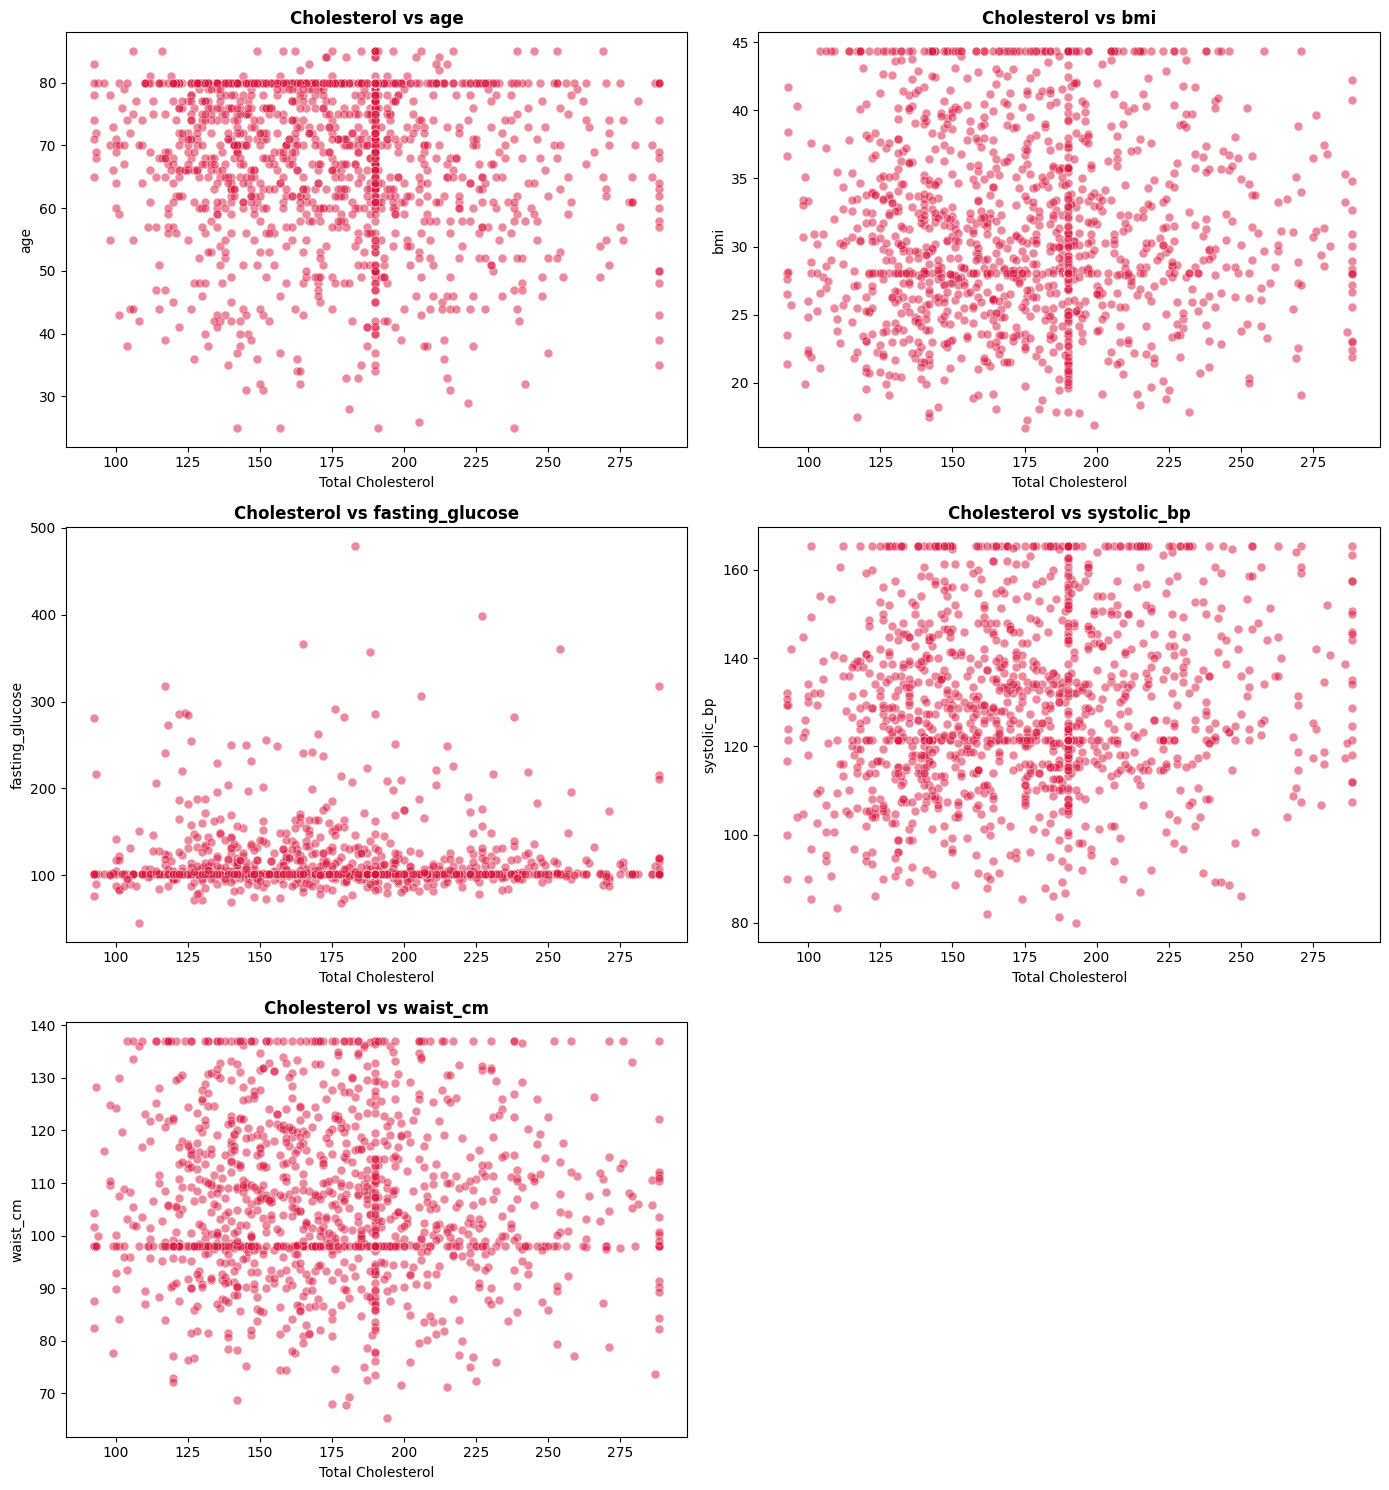

In [32]:
plot_features = ["age", "bmi", "fasting_glucose", "systolic_bp", "waist_cm"]
plot_features = [col for col in plot_features if col in eda_df.columns]

plot_df = eda_df[["total_cholesterol", "heart_failure"] + plot_features].dropna().copy()
plot_df = plot_df[plot_df["heart_failure"] == 1]

if len(plot_df) > 5000:
    plot_df = plot_df.sample(5000, random_state=42)

ncols = 2
nrows = int(np.ceil(len(plot_features) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
axes = np.atleast_1d(axes).reshape(-1)

for ax, feature in zip(axes, plot_features):
    sns.scatterplot(
        data=plot_df,
        x="total_cholesterol",
        y=feature,
        color="crimson",  
        alpha=0.5,
        s=40,
        ax=ax
    )
    ax.set_title(f"Cholesterol vs {feature}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Total Cholesterol")
    ax.set_ylabel(feature)

for ax in axes[len(plot_features):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

##### Phân tích mối tương quan giữa `total_cholesterol` và `age`
Trong nhóm bệnh nhân suy tim, dữ liệu cho thấy một sự phân tán rất rộng về độ tuổi, trải dài từ 30 đến hơn 80 tuổi. Tuy nhiên, mật độ tập trung cao nhất nằm ở phân khúc từ 55 đến 75 tuổi, phản ánh tính chất của suy tim là một bệnh lý liên quan chặt chẽ đến quá trình lão hóa. Đáng chú ý là không có một đường thẳng tương quan rõ rệt (correlation); điều này có nghĩa là một người trẻ tuổi với mức `total_cholesterol` thấp vẫn có nguy cơ suy tim tương đương với người cao tuổi có chỉ số tương tự trong tập dữ liệu này. Sự xuất hiện của các dải dọc ở mức `total_cholesterol` khoảng 190 mg/dL cho thấy đây có thể là một giá trị trung vị phổ biến.

##### Mối liên hệ với các chỉ số hình thể (`bmi` vs `waist_cm`)
Các biểu đồ liên quan đến `bmi` và `waist_cm` bộc lộ rõ đặc điểm nhân trắc học của nhóm bệnh nhân này. Đa số các điểm dữ liệu tập trung ở ngưỡng BMI từ 25 đến 40 và vòng eo từ 90cm đến 120cm, vốn là các dấu hiệu điển hình của tình trạng thừa cân và béo phì trung tâm. Mặc dù `total_cholesterol` không tăng tiến tỉ lệ thuận với kích thước cơ thể trên biểu đồ, nhưng sự hiện diện dày đặc của các giá trị cao ở cả hai trục cho thấy sự kết hợp giữa rối loạn lipid máu và béo phì là một "cặp bài trùng" thường thấy ở những người đã khởi phát suy tim.

##### Đánh giá đường huyết và áp lực dòng máu (`fasting_glucose` vs `systolic_bp`)
Biểu đồ giữa Cholesterol và đường huyết lúc đói `fasting_glucose` cho thấy một sự tập trung cực kỳ chặt chẽ ở ngưỡng dưới 150 mg/dL, với chỉ một vài điểm dị biệt (outliers) vọt lên trên 400 mg/dL. Điều này gợi ý rằng trong nhóm suy tim này, đa số bệnh nhân kiểm soát đường huyết ở mức ổn định hoặc tiền tiểu đường. Ngược lại, biểu đồ huyết áp tâm thu `systolic_bp` lại cho thấy mức độ dao động lớn hơn, tập trung nhiều ở khoảng 120-150 mmHg. Sự phân tán này chỉ ra rằng cao huyết áp thường xuyên đồng hành cùng mức `total_cholesterol` cao, tạo áp lực lớn lên hệ thống tim mạch của bệnh nhân.

##### Giải thích lý do cho mối tương quan âm (Negative Correlation)
Từ những quan sát trên, việc `heart_failure` có tương quan âm với `total_cholesterol` (tức là Cholesterol thấp lại hay đi kèm với suy tim) có thể được giải thích qua các lý do sau:
- Tác động của thuốc điều trị (Statins)
- Hiện tượng "Nghịch lý Obesity" (Obesity Paradox)
- Hiện tượng "Nghịch lý Cholesterol" (Cholesterol Paradox)

___

##### Xem mức độ liên hệ giữa các biến nguy cơ và suy tim.


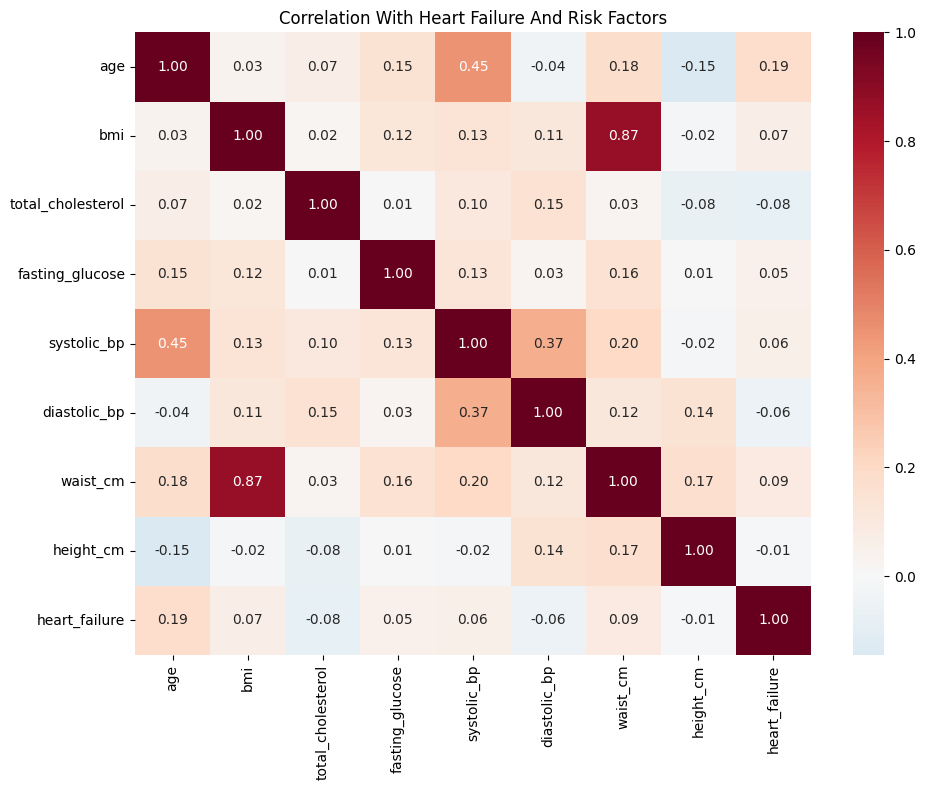

In [33]:
corr_features = [col for col in numeric_features if col in eda_df.columns]
if corr_features:
    plt.figure(figsize=(10, 8))
    corr = eda_df[corr_features + ["heart_failure"]].corr()
    sns.heatmap(corr, annot=True, cmap="RdBu_r", fmt=".2f", center=0)
    plt.title("Correlation With Heart Failure And Risk Factors")
    plt.tight_layout()
    plt.show()


Heatmap cho thấy `heart_failure` có xu hướng liên hệ mạnh hơn với các biến như `age`, `systolic_bp`, `waist_cm`, `bmi` hoặc `fasting_glucose` so với các biến khác. Tuy nhiên, điều quan trọng hơn là nhìn vào tương quan giữa các biến với nhau.

Với `bmi` và `waist_cm` tương quan cao, điều đó cho thấy hai biến này đang phản ánh cùng một phần thông tin về thể trạng và mỡ cơ thể. Trong trường hợp đó, mô hình có thể không cần phụ thuộc quá nhiều vào cả hai biến độc lập, nhưng việc giữ cả hai vẫn có ích nếu chúng đóng góp khác nhau ở từng mô hình phi tuyến.

Với `systolic_bp` và `diastolic_bp` không tương quan hoàn toàn đồng nhất, hoặc `systolic_bp` nổi bật hơn `diastolic_bp` trong liên hệ với `heart_failure`, điều đó ủng hộ ý tưởng rằng cấu trúc huyết áp là yếu tố quan trọng hơn từng chỉ số đơn lẻ. Đây cũng là cơ sở hợp lý cho biến `pulse_pressure` ở bước feature engineering.

Với `fasting_glucose` và `diabetes`, có tương quan dương nhưng không hoàn toàn trùng nhau, điều đó cho thấy hai biến này mang thông tin liên quan nhưng không giống hệt nhau. `Diabetes` phản ánh tình trạng bệnh nền đã được phân loại, trong khi `fasting_glucose` phản ánh mức độ sinh học cụ thể tại thời điểm đo. Hai biến này kết hợp có thể giúp mô hình nhìn rõ hơn nguy cơ chuyển hóa liên quan đến suy tim.

____

Giải thích mối tương quan âm giữa heart_failure và total_cholesterol, vui lòng đọc thêm về 'Cholesterol Paradox' & 'Obesity Paradox':
- https://www.news-medical.net/news/20250224/Higher-bad-cholesterol-levels-may-help-Sardiniae28099s-seniors-live-longer-study-finds.aspx
- https://academic.oup.com/eurheartj/article/41/Supplement_2/ehaa946.0451/6002932?login=false
- https://www.mdpi.com/2072-6643/17/5/765
- https://en.wikipedia.org/wiki/Obesity_paradox

___

## Feature Engineering & Model Building


##### Loại bớt biến không dùng trong bộ đặc trưng cuối.


In [34]:
dataset = dataset.drop('weight_kg', axis=1)

##### Sinh thêm các biến dẫn xuất phục vụ huấn luyện mô hình.


In [35]:
dataset['pulse_pressure'] = dataset['systolic_bp'] - dataset['diastolic_bp']

dataset['waist_height_ratio'] = dataset['waist_cm'] / dataset['height_cm']

##### Chuẩn bị X và y cho bước train mô hình.


In [36]:
X = dataset.drop('heart_failure', axis=1)
y = dataset['heart_failure']

##### Nạp các thư viện cần thiết cho bước chia dữ liệu, huấn luyện và đánh giá mô hình.

In [37]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import NearMiss

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("xgboost is not installed. Notebook will skip the XGBoost model.")

##### Tách tập dữ liệu và định nghĩa hàm undersampling (NearMiss) cho train set.

In [38]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42,
)

def undersample_training_data(X_train_df, y_train_series, majority_ratio=5, random_state=42):
    target_ratio = 1 / majority_ratio

    nearmiss = NearMiss(
        version=2,
        sampling_strategy=target_ratio,
        n_neighbors=3
    )

    X_resampled, y_resampled = nearmiss.fit_resample(X_train_df, y_train_series)

    X_resampled = pd.DataFrame(X_resampled, columns=X_train_df.columns)
    y_resampled = pd.Series(y_resampled, name=y_train_series.name or "heart_failure")

    return X_resampled, y_resampled

print(f"Original train shape: {X_train.shape}")
print(f"Validation shape: {X_valid.shape}")
print(f"Test shape: {X_test.shape}")
print("\nOriginal train class distribution:")
print(y_train.value_counts())

Original train shape: (30856, 14)
Validation shape: (3857, 14)
Test shape: (3857, 14)

Original train class distribution:
heart_failure
0    29788
1     1068
Name: count, dtype: int64


##### Định nghĩa các model sẽ so sánh và cách tính metric.

In [39]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(class_weight={0: 1, 1: 4}, C=0.8, max_iter=4000, random_state=42)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=250,
        max_depth=10,
        min_samples_split=30,
        min_samples_leaf=15,
        max_features="sqrt",
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1,
    )
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.04,
        min_child_weight=10,
        gamma=2,
        reg_lambda=8.0,
        subsample=0.8,
        colsample_bytree=0.7,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=5.0,
        random_state=42,
        n_jobs=-1,
    )

def evaluate_model(name, estimator, X_fit, y_fit, X_holdout, y_holdout):
    model = clone(estimator)
    model.fit(X_fit, y_fit)
    pred = model.predict(X_holdout)

    return {
        "name": name,
        "model": model,
        "precision": precision_score(y_holdout, pred, zero_division=0),
        "recall": recall_score(y_holdout, pred, zero_division=0),
        "f1": f1_score(y_holdout, pred, zero_division=0),
        "accuracy": accuracy_score(y_holdout, pred),
        "confusion_matrix": confusion_matrix(y_holdout, pred),
    }

X_train_under, y_train_under = undersample_training_data(
    X_train,
    y_train,
    majority_ratio=5,
    random_state=42,
)

print(f"\nUndersampled train shape: {X_train_under.shape}")
print("Undersampled train class distribution:")
print(y_train_under.value_counts())

validation_results = [
    evaluate_model(name, estimator, X_train_under, y_train_under, X_valid, y_valid)
    for name, estimator in models.items()
]

results_df = pd.DataFrame([
    {
        "model": item["name"],
        "precision": round(item["precision"], 4),
        "recall": round(item["recall"], 4),
        "f1": round(item["f1"], 4),
        "accuracy": round(item["accuracy"], 4),
    }
    for item in validation_results
]).sort_values(["f1", "recall"], ascending=False).reset_index(drop=True)

best_model_name = results_df.iloc[0]["model"]

X_train_valid = pd.concat([X_train, X_valid], axis=0).reset_index(drop=True)
y_train_valid = pd.concat([y_train, y_valid], axis=0).reset_index(drop=True)
X_train_valid_under, y_train_valid_under = undersample_training_data(
    X_train_valid,
    y_train_valid,
    majority_ratio=5,
    random_state=42,
)

final_results = [
    evaluate_model(name, estimator, X_train_valid_under, y_train_valid_under, X_test, y_test)
    for name, estimator in models.items()
]

final_results_df = pd.DataFrame([
    {
        "model": item["name"],
        "precision": round(item["precision"], 4),
        "recall": round(item["recall"], 4),
        "f1": round(item["f1"], 4),
        "accuracy": round(item["accuracy"], 4),
    }
    for item in final_results
]).sort_values(["f1", "recall"], ascending=False).reset_index(drop=True)

results_df


Undersampled train shape: (6408, 14)
Undersampled train class distribution:
heart_failure
0    5340
1    1068
Name: count, dtype: int64


,model,precision,recall,f1,accuracy
0,Logistic Regression,0.1100,0.6567,0.1884,0.8035
1,Random Forest,0.0329,0.7090,0.0629,0.2658
2,XGBoost,0.0323,0.7164,0.0619,0.2455


##### In metric trên validation, test và hiển thị confusion matrix cho từng model.

Validation metrics
                 model  precision  recall      f1  accuracy
0  Logistic Regression     0.1100  0.6567  0.1884    0.8035
1        Random Forest     0.0329  0.7090  0.0629    0.2658
2              XGBoost     0.0323  0.7164  0.0619    0.2455

Test metrics
                 model  precision  recall      f1  accuracy
0  Logistic Regression     0.1015  0.6090  0.1740    0.8006
1              XGBoost     0.0316  0.6992  0.0605    0.2515
2        Random Forest     0.0302  0.6541  0.0578    0.2647

Best model from validation: Logistic Regression


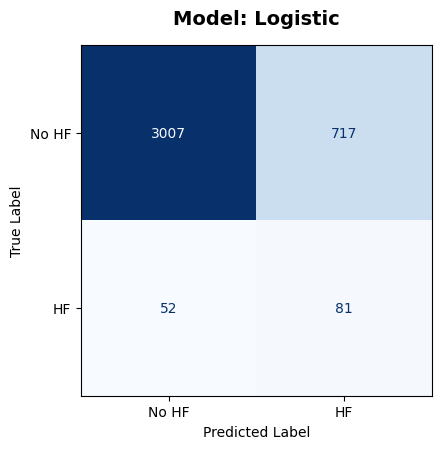

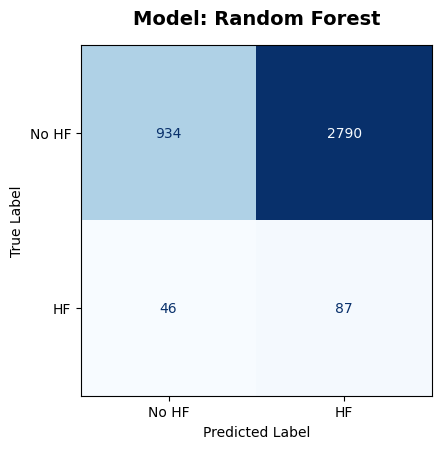

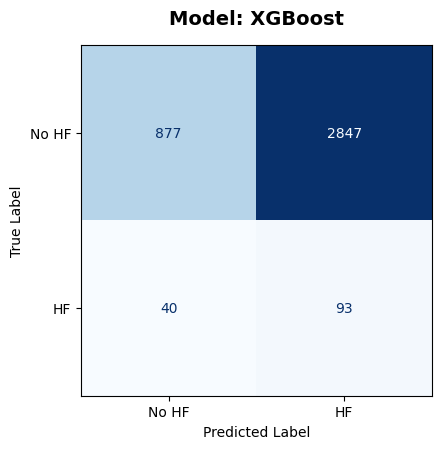

In [40]:
print("Validation metrics")
print(results_df)
print("\nTest metrics")
print(final_results_df)
print(f"\nBest model from validation: {best_model_name}")

class_labels = ["No HF", "HF"]
display_names = {
    "LogisticRegression": "Logistic",
    "RandomForestClassifier": "Random Forest",
    "XGBClassifier": "XGBoost",
}

for item in final_results:
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    
    raw_model = item["model"]
    
    if hasattr(raw_model, "steps"):
        model_type = type(raw_model.named_steps['model']).__name__
    else:
        model_type = type(raw_model).__name__

    clean_title = display_names.get(model_type, model_type)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=item["confusion_matrix"],
        display_labels=class_labels,
    )
    
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    
    ax.set_title(f"Model: {clean_title}", fontsize=14, weight="bold", pad=15)
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.set_ylabel("True Label", fontsize=10)
    
    ax.grid(False)
    plt.tight_layout()
    plt.show()

#### Lý Do Lựa Chọn Mô Hình

Trong bài toán dự đoán suy tim, dữ liệu có dạng bảng, số lượng biến không quá lớn nhưng có thể tồn tại cả quan hệ tuyến tính lẫn phi tuyến giữa các yếu tố nguy cơ và biến mục tiêu `heart_failure`. Vì vậy, nhóm mô hình được lựa chọn theo hướng vừa có mô hình đơn giản, dễ giải thích, vừa có mô hình mạnh hơn để khai thác các mối quan hệ phức tạp trong dữ liệu.

##### Logistic Regression
Logistic Regression được sử dụng như một mô hình baseline quan trọng cho bài toán phân loại nhị phân. Mô hình này có ưu điểm là đơn giản, dễ diễn giải và huấn luyện nhanh. Với dữ liệu y tế, Logistic Regression thường được dùng như một điểm tham chiếu ban đầu để kiểm tra xem các đặc trưng hiện có đã mang đủ tín hiệu để phân biệt nguy cơ suy tim hay chưa. Ngoài ra, mô hình này cũng phù hợp khi cần giải thích xu hướng ảnh hưởng của từng biến một cách trực quan hơn.

##### Random Forest
Random Forest là mô hình ensemble dựa trên nhiều cây quyết định, phù hợp với dữ liệu bảng và có khả năng học được các quan hệ phi tuyến giữa các biến đầu vào. Mô hình này ít nhạy với phân phối dữ liệu hơn so với các mô hình tuyến tính và thường cho kết quả ổn định trong các bài toán phân loại y tế. Random Forest được chọn vì có thể khai thác tốt các tương tác giữa tuổi, BMI, huyết áp, glucose, cholesterol và các yếu tố hành vi như hút thuốc hay vận động.

##### XGBoost
XGBoost là một trong những mô hình boosting mạnh và phổ biến nhất cho dữ liệu bảng. Mô hình này thường đạt hiệu quả cao trong các bài toán dự đoán rủi ro y tế nhờ khả năng học tốt các tương tác phi tuyến, đồng thời có nhiều cơ chế regularization để giảm overfitting. Trong notebook này, XGBoost được sử dụng như một mô hình nâng cao để đối chiếu với các mô hình còn lại và kiểm tra xem boosting có mang lại cải thiện rõ rệt hay không.

##### Tại Sao Chọn Bộ Mô Hình Này
Nhóm mô hình trên được lựa chọn nhằm bao phủ nhiều hướng tiếp cận khác nhau:
- Logistic Regression đại diện cho mô hình tuyến tính, đơn giản và dễ giải thích.
- Random Forest đại diện cho nhóm ensemble bagging dựa trên cây.
- XGBoost đại diện cho nhóm boosting, có khả năng học các quan hệ phức tạp hơn.

Cách lựa chọn này giúp quá trình so sánh mô hình toàn diện hơn, thay vì chỉ phụ thuộc vào một loại thuật toán duy nhất. Đồng thời, đây đều là các mô hình phù hợp với dữ liệu bảng và thường được sử dụng hiệu quả trong các bài toán phân loại rủi ro sức khỏe.

##### Tại Sao Cần NearMiss Trước Khi Huấn Luyện
Biến mục tiêu `heart_failure` trong dữ liệu bị mất cân bằng rõ rệt, với số mẫu không suy tim lớn hơn nhiều so với số mẫu suy tim. Nếu huấn luyện trực tiếp trên dữ liệu gốc, mô hình dễ thiên về lớp đa số và cho độ chính xác cao nhưng nhận diện kém lớp bệnh. Vì vậy, phương pháp NearMiss được áp dụng trên tập train để giảm số mẫu của lớp đa số một cách có chọn lọc.

Khác với random undersampling, NearMiss không loại bỏ mẫu ngẫu nhiên mà ưu tiên giữ lại các mẫu lớp đa số nằm gần lớp thiểu số nhất. Nhờ đó, mô hình tập trung hơn vào vùng ranh giới phân loại, nơi việc phân biệt giữa người có và không có nguy cơ suy tim là khó hơn. Điều này phù hợp với mục tiêu của bài toán là cải thiện khả năng phát hiện lớp bệnh.

Mô hình tập trung vào Recall, do đó các thông số khác như Precision có thể sẽ thấp hơn bình thường

In [41]:
def get_positive_probability(model, X_data):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]

    if hasattr(model, "decision_function"):
        scores = model.decision_function(X_data)
        scores = np.asarray(scores, dtype=float)

        if scores.max() == scores.min():
            return np.full_like(scores, 0.5, dtype=float)

        return (scores - scores.min()) / (scores.max() - scores.min())

    pred = model.predict(X_data)
    return np.asarray(pred, dtype=float)


trained_models = {item["name"]: item["model"] for item in final_results}

weights = {
    "Logistic Regression": 0.6,
    "Random Forest": 0.2,
    "XGBoost": 0.2,
}

print("Nhap du lieu moi de du doan")
print("Cac bien nhi phan nhap 0 hoac 1.\n")

input_fields = [
    "age",
    "sex_Male",
    "bmi",
    "height_cm",
    "waist_cm",
    "systolic_bp",
    "diastolic_bp",
    "total_cholesterol",
    "fasting_glucose",
    "diabetes",
    "smoking_100_cigs_life",
    "moderate_activity",
]

binary_cols = {
    "sex_Male",
    "diabetes",
    "smoking_100_cigs_life",
    "moderate_activity",
}

new_sample = {}

for col in input_fields:
    while True:
        try:
            if col in binary_cols:
                value = int(input(f"{col} (0/1): "))
                if value not in [0, 1]:
                    print("Chi nhap 0 hoac 1.")
                    continue
            else:
                value = float(input(f"{col}: "))
            new_sample[col] = value
            break
        except ValueError:
            print("Gia tri khong hop le. Vui long nhap lai.")

new_sample["pulse_pressure"] = new_sample["systolic_bp"] - new_sample["diastolic_bp"]
new_sample["waist_height_ratio"] = new_sample["waist_cm"] / new_sample["height_cm"]

new_sample_df = pd.DataFrame([new_sample]).reindex(columns=X.columns)

if new_sample_df.isnull().sum().sum() > 0:
    missing_cols = new_sample_df.columns[new_sample_df.isnull().any()].tolist()
    raise ValueError(f"Thieu gia tri o cac cot: {missing_cols}")

missing_weights = [name for name in trained_models if name not in weights]
if missing_weights:
    raise ValueError(f"Thieu trong so cho cac model: {missing_weights}")

model_probabilities = {}

for name, model in trained_models.items():
    prob = get_positive_probability(model, new_sample_df)[0]
    model_probabilities[name] = prob

ensemble_probability = sum(
    model_probabilities[name] * weights[name]
    for name in model_probabilities
)

threshold = 0.65
ensemble_prediction = int(ensemble_probability >= threshold)

print("\nDu doan tung mo hinh:")
for name, prob in model_probabilities.items():
    print(f"- {name}: {prob:.4f} | weight = {weights[name]}")

print(f"\nXac suat ensemble co trong so: {ensemble_probability:.4f}")
print(f"Threshold: {threshold}")
print(f"Ket luan cuoi cung: {'Heart Failure' if ensemble_prediction == 1 else 'No Heart Failure'}")

Nhap du lieu moi de du doan
Cac bien nhi phan nhap 0 hoac 1.


Du doan tung mo hinh:
- Logistic Regression: 0.8264 | weight = 0.6
- Random Forest: 0.8835 | weight = 0.2
- XGBoost: 0.9909 | weight = 0.2

Xac suat ensemble co trong so: 0.8708
Threshold: 0.65
Ket luan cuoi cung: Heart Failure
